[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2021 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

WIP...
The project is currently under heavy development while adding new material for the summer semester 2021

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Übung / Exercise 9 / 10

Discrete-Time, Linear, Time-Invariant (DTLTI) System Analysis for

- FIR...finite impulse response, i.e. we actually refer to a non-recursive system
- IIR...infinite impulse response, i.e. we actually refer to a recursive system

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from scipy.fftpack import fft
from scipy.signal import dimpulse, dstep, dfreqresp, dbode
from scipy.signal import TransferFunction, ZerosPolesGain, bilinear
from scipy.signal import tf2zpk, dlti

In [2]:
cur_fol = os.getcwd()
print(cur_fol)
sys.path.append(cur_fol + '/../')

/Users/fs446/git/signals-and-systems-exercises/z_system_analysis


In [3]:
from sig_sys_tools import plot_zplane

In [4]:
Nf = 2**10  # values along frequency axis
Om = np.arange(Nf) * (2*np.pi/Nf)  # get frequency vector for bode, fft

# IIR System

task 542FA69517, 9.1

In [5]:
# IIR filter, 2-poles, 2-zeros system
b = [2, -2*1/np.sqrt(2), 0]
a = [1, -np.sqrt(2), 1]
Nt = 10  # values along time axis
fir_flag = False

# IIR System

task EF72605A91, 9.2

In [6]:
# IIR filter, 2-poles, 2-zeros system
b = [0, 2*3*np.sqrt(3)/8, 0]
a = [1, -3/4, 9/16]
Nt = 10  # values along time axis
fir_flag = False

# IIR System

task A1D74A9E5B, 9.3

In [7]:
# IIR filter, 2-poles, 2-zeros system
zp = 1/2
b = np.array([1, 0])  # * (1-zp)  # normalize such that DC 0dB & he[k->oo] =1
a = np.array([1, -zp])
Nt = 2**6  # values along time axis
fir_flag = False

# IIR System

task 542FA69517, 9.4

In [8]:
# IIR filter, 2-poles, 2-zeros system
b = [+1, -1, +2]
a = [+1, -1/2, +1/4]
Nt = 10  # values along time axis
fir_flag = False

# FIR System

task 64BE42BAEF, 10.2

In [9]:
# coeff H(z) = bz / az for FIR, length(a)==length(b)!
b = np.array([1, 0, 1, 0, 17/4, 0, 17/4, 0, 1, 0, 1])
a = np.zeros_like(b)
a[0] = 1
Nt = 2**4  # values along time axis
fir_flag = True

# System Descriptions

In [10]:
z, p, k = tf2zpk(b, a)

# possible descriptions from scipy.signal package
sys1 = dlti(b, a)
sys2 = TransferFunction(b, a, dt=True)
sys3 = dlti(z, p, k)
sys4 = ZerosPolesGain(z, p, k, dt=True)

sys = sys1  # use one of the above possibilities

# Impulse Response

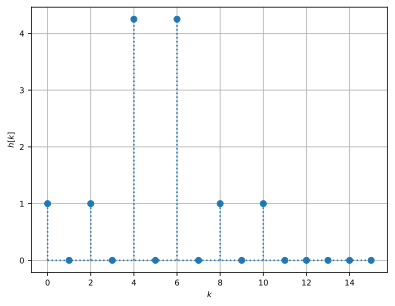

In [11]:
h = dimpulse(sys, n=Nt)
plt.stem(np.squeeze(h[0]), np.squeeze(h[1]),
         use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.xlabel(r'$k$')
plt.ylabel(r'$h[k]$')
plt.grid(True)

# Step Response

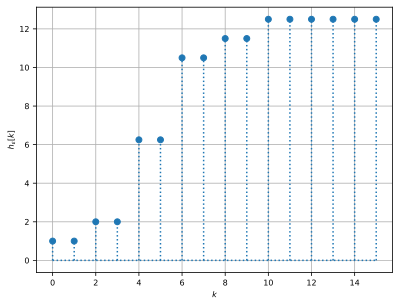

In [12]:
he = dstep(sys, n=Nt)
plt.stem(np.squeeze(he[0]), np.squeeze(he[1]),
         use_line_collection=True,
         linefmt='C0:', markerfmt='C0o', basefmt='C0:')
plt.xlabel(r'$k$')
plt.ylabel(r'$h_\epsilon[k]$')
plt.grid(True)

# Pole / Zero / Gain Map

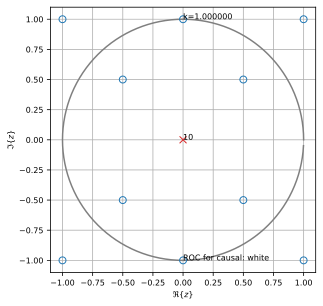

In [13]:
plot_zplane(z, p, k)

# Bode Plot

<ipython-input-1-0c3a3a2300bb>:19: RuntimeWarning: divide by zero encountered in log10
  plt.plot(Om, 20*np.log10(np.abs(Hfft)))


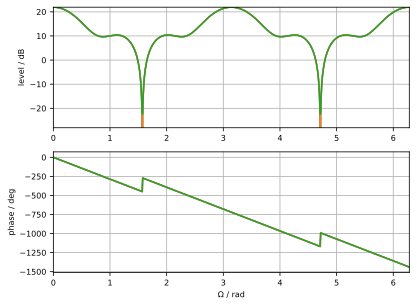

In [14]:
_, level, phase = dbode(sys, Om)
_, H = dfreqresp(sys, Om)

Hmax = np.max(level)
Hmin = Hmax - 50
if Hmax == np.inf:  # not nice code, but for poles ON the unit circle we need
    # some special treatment
    Hmax = 50
    Hmin = 0

if fir_flag:
    # for FIR filters we can also utilize the FFT of the b-coefficients as
    Hfft = fft(b, Nf)  # zeropadded FFT is interpolation towards DTFT

plt.subplot(2, 1, 1)
plt.plot(Om, level)
plt.plot(Om, 20*np.log10(np.abs(H)))
if fir_flag:
    plt.plot(Om, 20*np.log10(np.abs(Hfft)))
plt.xlim(0, 2*np.pi)
plt.ylim(Hmin, Hmax)
#plt.xlabel(r'$\Omega$ / rad')
plt.ylabel(r'level / dB')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(Om, phase)
plt.plot(Om, np.unwrap(np.angle(H))*180/np.pi)
if fir_flag:
    plt.plot(Om, np.unwrap(np.angle(Hfft))*180/np.pi)
plt.xlim(0, 2*np.pi)
plt.xlabel(r'$\Omega$ / rad')
plt.ylabel(r'phase / deg')
plt.grid(True)

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``main file, github URL, commit number and/or version tag, year``.